In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("/content/global_power_plant_database.csv")

missing_counts = df.isnull().sum()
print(df.shape)
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame(
    {
        'Missing Count': missing_counts,
        'Missing %': missing_pct
    })
print(missing_df)

df = df.drop(columns=['other_fuel1'])
df = df.drop(columns=['other_fuel2'])
df = df.drop(columns=['other_fuel3'])
#df = df.drop(columns=['commissioning_year'])
df = df.drop(columns=['wepp_id'])
df = df.drop(columns=['year_of_capacity_data'])
df = df.drop(columns=['generation_gwh_2013'])
df = df.drop(columns=['generation_gwh_2014'])
df = df.drop(columns=['generation_gwh_2015'])
df = df.drop(columns=['generation_gwh_2016'])
df = df.drop(columns=['generation_gwh_2017'])
df = df.drop(columns=['generation_gwh_2018'])
df = df.drop(columns=['generation_gwh_2019'])
df = df.drop(columns=['generation_data_source'])
df = df.drop(columns=['estimated_generation_gwh_2013'])
df = df.drop(columns=['estimated_generation_gwh_2014'])
df = df.drop(columns=['estimated_generation_gwh_2015'])

df.dropna(subset=['source'], inplace=True)
df.dropna(subset=['url'], inplace=True)
df.dropna(subset=['geolocation_source'], inplace=True)

df['owner'] = df['owner'].fillna('Unknown')
df['estimated_generation_gwh_2016'] = df['estimated_generation_gwh_2016'].fillna('Unknown')
df['estimated_generation_gwh_2017'] = df['estimated_generation_gwh_2017'].fillna('Unknown')

df['capacity_mw'] = pd.to_numeric(df['capacity_mw'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')


/tmp/ipykernel_658/2558359543.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/global_power_plant_database.csv")


(34936, 36)
                                Missing Count  Missing %
country                                     0   0.000000
country_long                                0   0.000000
name                                        0   0.000000
gppd_idnr                                   0   0.000000
capacity_mw                                 0   0.000000
latitude                                    0   0.000000
longitude                                   0   0.000000
primary_fuel                                0   0.000000
other_fuel1                             32992  94.435539
other_fuel2                             34660  99.209984
other_fuel3                             34844  99.736661
commissioning_year                      17489  50.060110
owner                                   14068  40.267918
source                                     15   0.042936
url                                        18   0.051523
geolocation_source                        419   1.199336
wepp_id            

In [12]:
# Statistical summary of numerical columns
summary_stats = df[['capacity_mw', 'latitude', 'longitude']].describe()

# Count plants by primary fuel type
fuel_distribution = df['primary_fuel'].value_counts()

# Count plants by top 10 countries
country_distribution = df['country_long'].value_counts().head(10)

print("Key Statistics for Capacity (MW):")
print(f"Mean: {summary_stats.loc['mean', 'capacity_mw']:.2f}")
print(f"Median: {df['capacity_mw'].median():.2f}")
print(f"Std Dev: {summary_stats.loc['std', 'capacity_mw']:.2f}")

Key Statistics for Capacity (MW):
Mean: 156.75
Median: 16.00
Std Dev: 458.00


In [13]:
from scipy import stats

# Calculate mean and std for each fuel type using NumPy
fuel_types = df['primary_fuel'].unique()
for fuel in fuel_types:
    subset = df[df['primary_fuel'] == fuel]['capacity_mw'].values
    print(f"{fuel}: Mean={np.mean(subset):.2f} MW, Std={np.std(subset):.2f}")

# Hypothesis Testing: One-way ANOVA
# Null Hypothesis (H0): Mean capacity is the same for all fuel types.
groups = [df[df['primary_fuel'] == f]['capacity_mw'] for f in fuel_types]
f_stat, p_val = stats.f_oneway(*groups)

print(f"\nANOVA Results: F-statistic = {f_stat:.2f}, p-value = {p_val:.4e}")

Hydro: Mean=123.36 MW, Std=412.69
Solar: Mean=17.59 MW, Std=42.08
Gas: Mean=364.76 MW, Std=559.71
Other: Mean=84.02 MW, Std=144.19
Oil: Mean=112.55 MW, Std=392.28
Wind: Mean=47.64 MW, Std=67.75
Nuclear: Mean=2056.65 MW, Std=1286.79
Coal: Mean=843.84 MW, Std=888.10
Waste: Mean=13.81 MW, Std=20.57
Biomass: Mean=23.97 MW, Std=39.45
Wave and Tidal: Mean=55.22 MW, Std=96.24
Petcoke: Mean=202.05 MW, Std=456.68
Geothermal: Mean=67.13 MW, Std=114.34
Storage: Mean=12.68 MW, Std=35.44
Cogeneration: Mean=98.73 MW, Std=279.95

ANOVA Results: F-statistic = 1122.03, p-value = 0.0000e+00


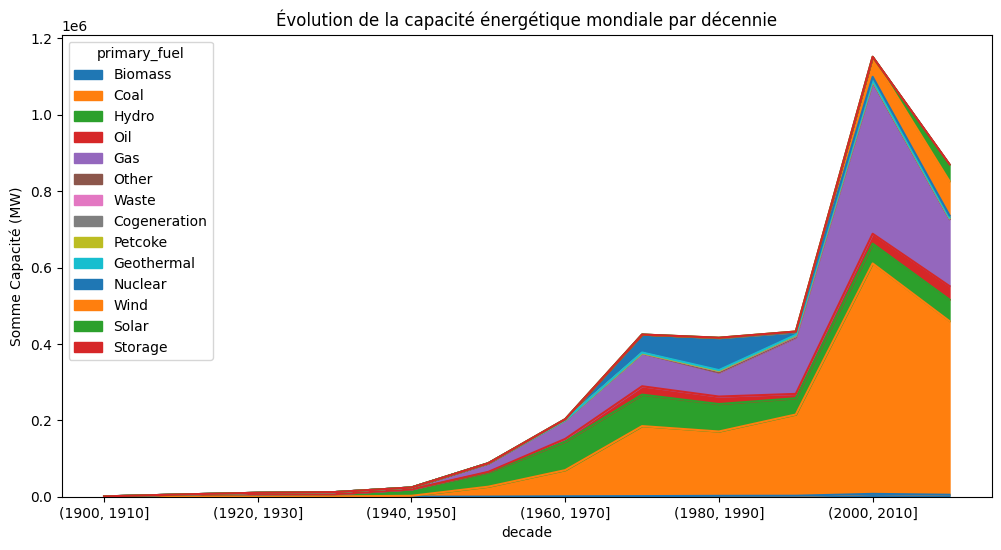

In [14]:
bins = np.arange(1900, 2030, 10)
df['decade'] = pd.cut(df['commissioning_year'], bins=bins)

# Évolution du mix énergétique
ts_analysis = df.groupby(['decade', 'primary_fuel'], observed=True)['capacity_mw'].sum().unstack().fillna(0)

ts_analysis.plot(kind='area', stacked=True, figsize=(12, 6))
plt.title("Évolution de la capacité énergétique mondiale par décennie")
plt.ylabel("Somme Capacité (MW)")
plt.show()

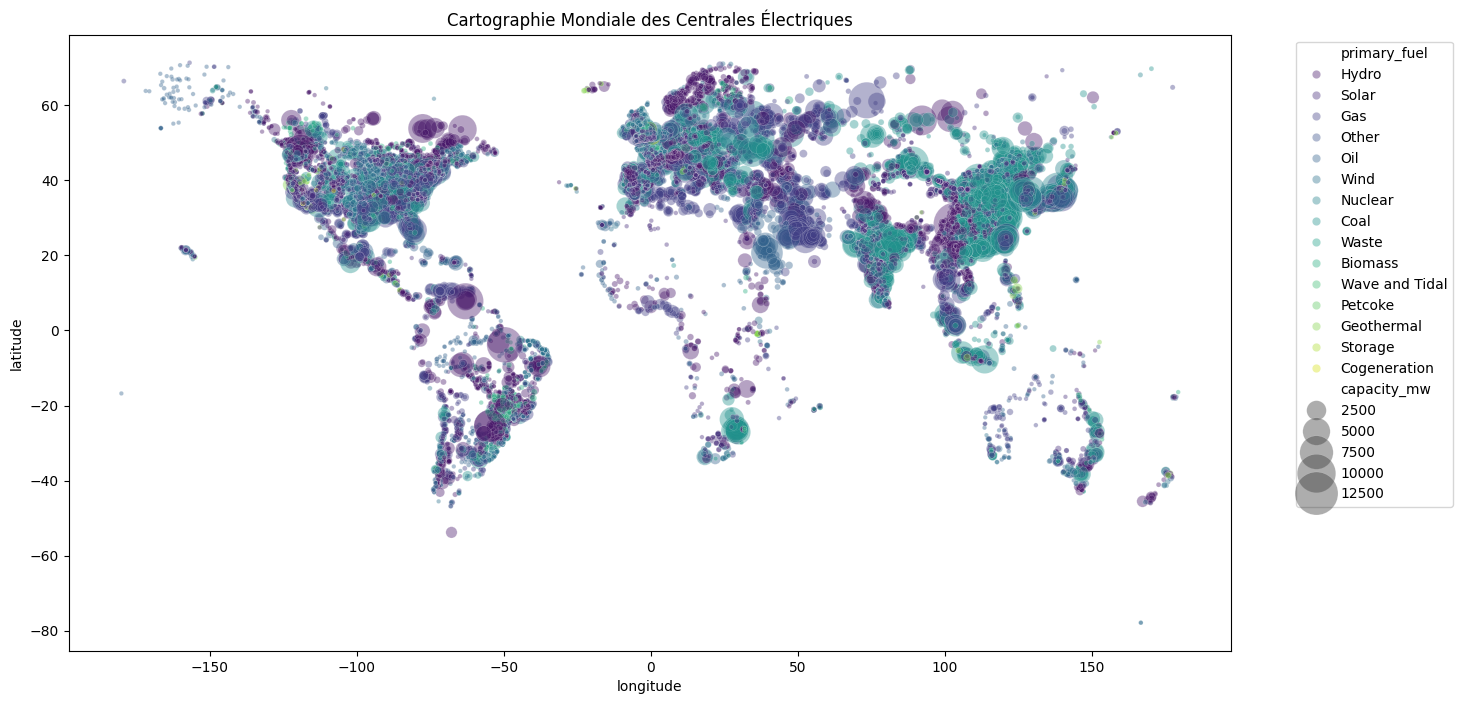

In [15]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='longitude', y='latitude',
                hue='primary_fuel', size='capacity_mw',
                sizes=(10, 1000), alpha=0.4, palette='viridis')
plt.title("Cartographie Mondiale des Centrales Électriques")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [16]:
# Sélection des colonnes pour la matrice
features = df[['capacity_mw', 'latitude', 'longitude']].dropna().values

# Calcul de la matrice de covariance
cov_matrix = np.cov(features.T)

# Calcul des valeurs propres (eigenvalues) et vecteurs propres (eigenvectors)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Valeurs Propres :", eigenvalues)
# Discussion : Une valeur propre très élevée par rapport aux autres indique
# que cette composante (direction) capture la majorité de la variance des données.

Valeurs Propres : [209888.5581737    5932.10412946    515.40700329]


In [18]:
# On prend la colonne 'capacity_mw' et on la transforme en tableau NumPy
capacity_np = df['capacity_mw'].to_numpy(dtype=np.float64)

# Calcul du Z-score avec NumPy pour un filtrage rapide
z_scores = np.abs((capacity_np - np.mean(capacity_np)) / np.std(capacity_np))

# Masque booléen NumPy appliqué au DataFrame Pandas
df_outliers = df[z_scores > 3]

print(f"Nombre de centrales considérées comme 'Giga-projets' (Outliers) : {len(df_outliers)}")

Nombre de centrales considérées comme 'Giga-projets' (Outliers) : 720
